In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

### Training performances

In [2]:
N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
dfs = []
for layer in N_LAYERS:
    df = pd.read_csv(f"Results/test_metrics/{layer}layers/test_metrics_{layer}layers.csv")
    df_hist = pd.read_csv(f"Results/train_history/{layer}layers/train_history_{layer}layers.csv")
    df = df.drop(columns=["output"])
    df["best_val"] = np.min(df_hist["val_loss"].values)
    df["epochs"] = df_hist["epoch"].values.tolist()[-1]
    df.insert(0, "num_layers", [layer])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

In [3]:
df_all

,num_layers,R2,RMSE,MAE,best_val,epochs
0,3,0.698622,7.487138,5.833248,0.155557,33
1,5,0.698010,7.494740,5.841167,0.158466,38
2,7,0.674122,7.785518,5.975801,0.157426,47
3,9,0.688740,7.608894,5.989590,0.158600,41
4,11,0.698269,7.491516,5.855290,0.158374,34
5,13,0.690058,7.592772,5.965261,0.154560,36
6,15,0.683662,7.670712,5.924325,0.157013,45
7,17,0.696140,7.517903,5.966175,0.157087,35
8,20,0.692473,7.563128,5.924075,0.160073,43


In [4]:
df_mlp = pd.read_csv(f"Results_MLP/test_metrics/test_metrics.csv")
df_mlp_hist = pd.read_csv(f"Results_MLP/train_history/train_history.csv")
df_mlp = df_mlp.drop(columns=["output"])
df_mlp["best_val"] = np.min(df_mlp_hist["val_loss"].values)
df_mlp["epochs"] = df_mlp_hist["epoch"].values.tolist()[-1]
df_mlp

,R2,RMSE,MAE,best_val,epochs
0,0.692725,7.560029,6.008455,0.161415,18


In [5]:
train_loss = df_mlp_hist["train_loss"].to_numpy()
val_loss = df_mlp_hist["val_loss"].to_numpy()

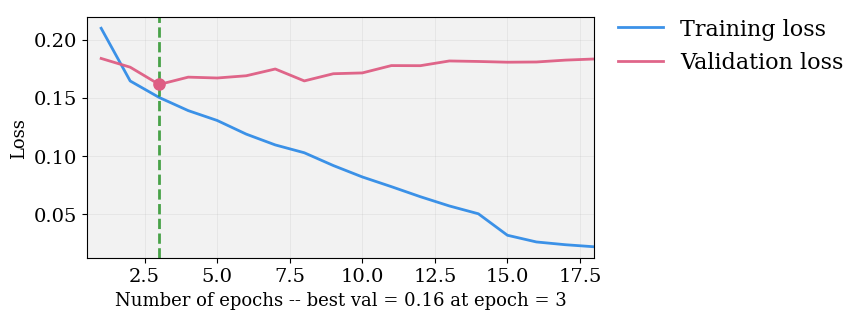

In [6]:
plt.rcParams["font.family"] = "serif"
train_color = "#318CE7"
val_color = "#DE5D83"

fig, ax = plt.subplots(figsize=(6, 3), constrained_layout=True)

train = np.asarray(train_loss)
val = np.asarray(val_loss)

n_epochs = len(train)
e = np.arange(1, n_epochs + 1)
        
best_epoch = np.argmin(val) + 1
best_val = np.min(val)

ax.plot(e, train, linewidth=2.0, alpha=0.95, color=train_color, label="Training loss")
ax.plot(e, val, linewidth=2.0, alpha=0.95, color=val_color, label="Validation loss")

ax.axvline(best_epoch, linestyle="--", linewidth=2, alpha=0.7, color="green")
ax.scatter(best_epoch, best_val, s=65, zorder=5, color=val_color)

ax.set_xlim([0.5, n_epochs])

# ax.set_yticks([0.1, 0.2])
        
ax.set_xlabel(f"Number of epochs -- best val = {best_val:.2f} at epoch = {best_epoch}", 
              fontsize=13)
    
ax.set_facecolor("#f2f2f2")

ax.grid(True, linewidth=0.4, alpha=0.3)
ax.tick_params(axis='both', labelsize=14)

handles, labels = ax.get_legend_handles_labels()

ax.set_ylabel("Loss", fontsize=13)

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.43, 1.05),
    ncol=1,
    fontsize=16,
    frameon=False
)  
# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
# plt.savefig("Results/losses_MLP.pdf", bbox_inches="tight")
plt.show()

### SHAP values

In [7]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

/tmp/ipykernel_309958/1026873776.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


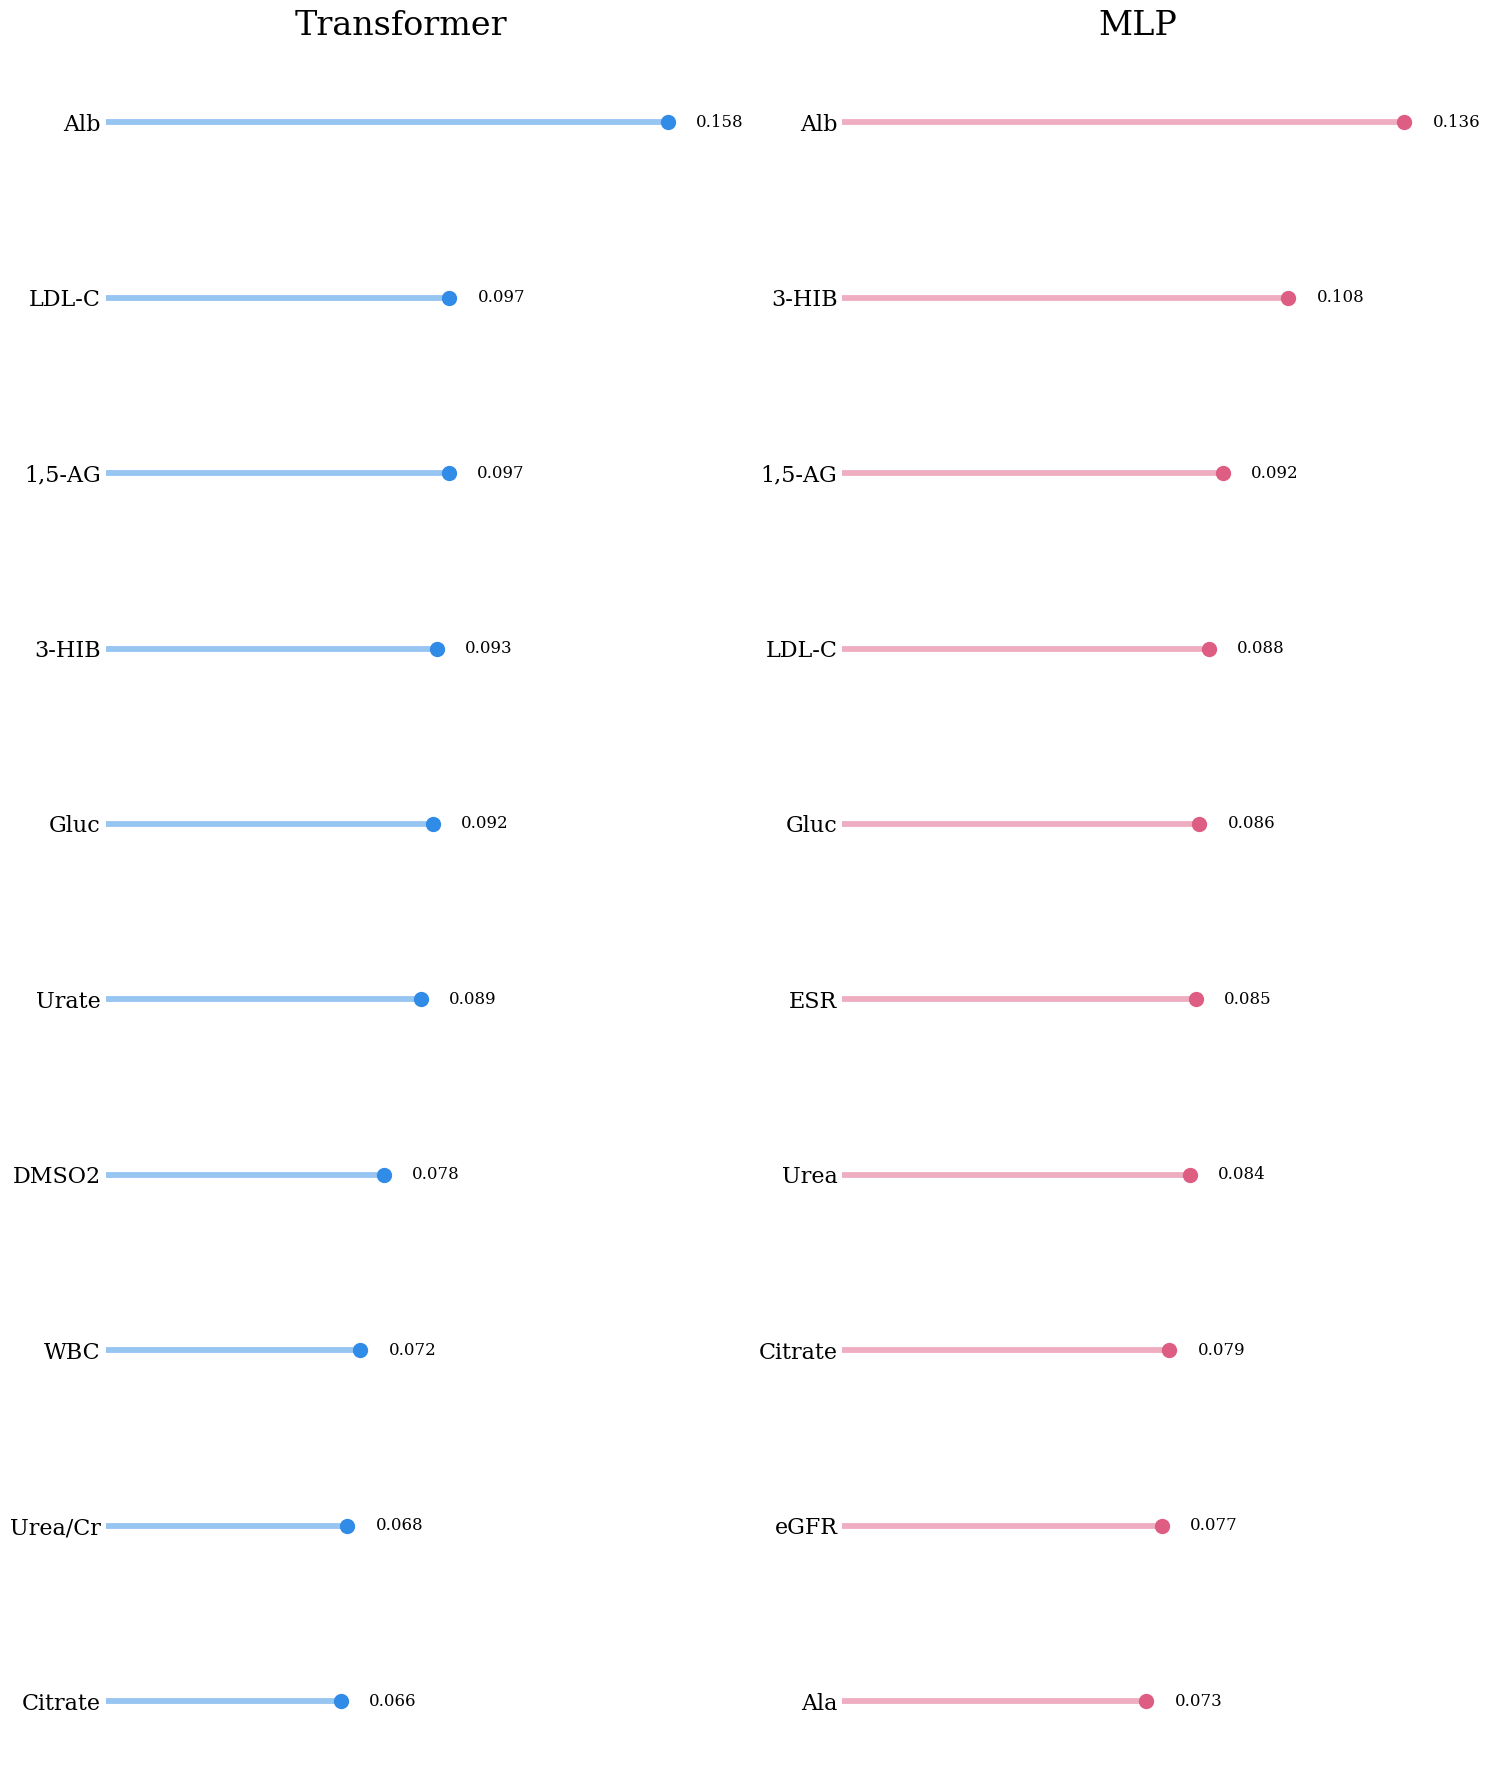

In [15]:
plt.rcParams["font.family"] = "serif"
l = 11

df_tr = pd.read_csv(f"Results/shap_values/tables/{l}layers/shap_scores{l}layers_unsorted.csv")
df_mlp = pd.read_csv(f"Results_MLP/shap_values/tables/shap_scores_unsorted.csv")

scores_dict = {"Transformer": df_tr["score"].to_numpy(),
               "MLP": df_mlp["score"].to_numpy()}

feature_dict = {"Transformer": df_tr["feature"].values.tolist(),
                "MLP": df_mlp["feature"].values.tolist()}

colors_dict = {"Transformer": "#318CE7",
               "MLP": "#DE5D83"}

fig, axes = plt.subplots(1, 2, figsize=(15, 18), constrained_layout=True)

k=10

for ax, (title, scores) in zip(axes, scores_dict.items()):

    # print(scores)
    idx = np.argsort(scores)[-k:][::-1]        
    top_scores = scores[idx]
    top_features = [feature_abbrev[i] for i in idx]
    
    top_scores_norm = top_scores / np.max(top_scores)

    y = np.arange(k)

    for yi, val in zip(y, top_scores_norm):
        ax.hlines(y=yi, xmin=0, xmax=val, linewidth=4.2, 
                  color=colors_dict[title], alpha=0.5)        
        ax.plot(val, yi, 'o', markersize=10, color=colors_dict[title])

    # --- Labels ---
    ax.set_xticks([])
    ax.set_yticks(y)
    ax.set_yticklabels(top_features, fontsize=16)

    ax.invert_yaxis()

    ax.set_title(title, fontsize=24)

    ax.set_xlim(0, 1.05)

    xmax = top_scores_norm.max()
    for j, value in enumerate(top_scores_norm):        
        ax.text(value + 0.05 * xmax, j, 
                f"{top_scores[j]:.3f}", va="center", 
                fontsize=12)

    # Clean style similar to your figure
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    ax.tick_params(axis='y', length=0)

    ax.grid(False)

plt.tight_layout()

# plt.savefig(f"Results/feature_importance_plots/top{k}scores_L{l}.pdf", bbox_inches="tight")

plt.show()

In [16]:
def topk_overlap(rank1, rank2, k):
    s1 = set(rank1[:k])
    s2 = set(rank2[:k])
    return len(s1 & s2)/k

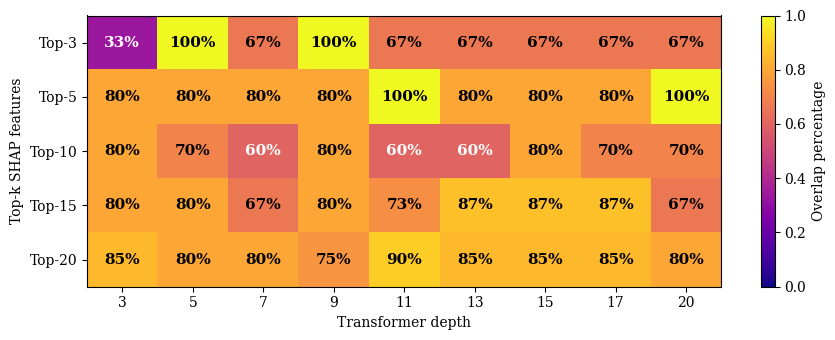

In [33]:
NUM_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
TOPKS = [3, 5, 10, 15, 20]

cmap = "plasma"

# Load MLP ranking once
df_mlp = pd.read_csv(
    "Results_MLP/shap_values/tables/shap_scores.csv"
)

heatmap_data = []

for k in TOPKS:

    mlp_topk = set(df_mlp["original_position"].iloc[:k])

    overlaps = []

    for layer in NUM_LAYERS:

        df_tr = pd.read_csv(
            f"Results/shap_values/tables/{layer}layers/shap_scores{layer}layers.csv"
        )

        tr_topk = set(df_tr["original_position"].iloc[:k])

        overlap_fraction = len(
            tr_topk.intersection(mlp_topk)
        ) / k

        overlaps.append(overlap_fraction)

    heatmap_data.append(overlaps)

heatmap_data = np.array(heatmap_data)

fig, ax = plt.subplots(figsize=(9, 3.5))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=1
)

# x-axis
ax.set_xticks(range(len(NUM_LAYERS)))
ax.set_xticklabels(NUM_LAYERS)

# y-axis
ax.set_yticks(range(len(TOPKS)))
ax.set_yticklabels([f"Top-{k}" for k in TOPKS])

# annotations
for i, k in enumerate(TOPKS):

    for j in range(len(NUM_LAYERS)):

        frac = heatmap_data[i, j]
        percentage = 100 * frac

        text_color = "white" if frac <= 0.6 else "black"

        ax.text(
            j, i,
            f"{percentage:.0f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color
        )       
        

cbar = plt.colorbar(im)
cbar.set_label("Overlap percentage")

ax.set_xlabel("Transformer depth")
ax.set_ylabel("Top-k SHAP features")

plt.tight_layout()

plt.savefig("Results/feature_importance_plots/mlp_transformer_overlap.pdf", 
            bbox_inches="tight")

plt.show()